Download the prerequisites
1. Tensorflow
2. Numpy
3. Matplotlib
4. Gradio
5. Sklearn
6. Seaborn

In [37]:
%pip install tensorflow
%pip install numpy
%pip install matplotlib
%pip install Gradio
%pip install scikit-learn
%pip install seaborn

13777.28s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13783.11s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13788.92s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


...


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13800.69s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 3.5 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 1.9 MB/s  0:00:18m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


13837.83s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


DATA ACQUISITION
Step 1: Load the Datasets

legend:
data_dir = directory of the data / data path
train_ds = means train Data set
validation_ds = means Validation Dataset

In [11]:
import tensorflow as tf

data_dir = "cat_breeds"
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset="training",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(180, 180),
    batch_size=32
)

Found 1349 files belonging to 10 classes.
Using 1080 files for training.
Found 1349 files belonging to 10 classes.
Using 269 files for validation.


E0000 00:00:1788531114.326055   43389 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Data Exploration

In [18]:
#print the shape of the loaded data
# Grab one batch from the training set
for images, labels in train_ds.take(1):
    print("Train batch X shape (images):", images.shape)
    print("Train batch y shape (labels):", labels.shape)

# Grab one batch from the validation set
for images, labels in validation_ds.take(1):
    print("Validation batch X shape (images):", images.shape)
    print("Validation batch y shape (labels):", labels.shape)

Train batch X shape (images): (32, 180, 180, 3)
Train batch y shape (labels): (32,)
Validation batch X shape (images): (32, 180, 180, 3)
Validation batch y shape (labels): (32,)


In [13]:
#Print the class names
print("Cat breeds:", train_ds.class_names)
#Print the number of classes
print("Number of cat breeds:", len(train_ds.class_names))

Cat breeds: ['abyssinian', 'bengal', 'birman', 'british_shorthair', 'maine_coon', 'oriental_shorthair', 'persian', 'siamese', 'sphynx', 'turkish_van']
Number of cat breeds: 10


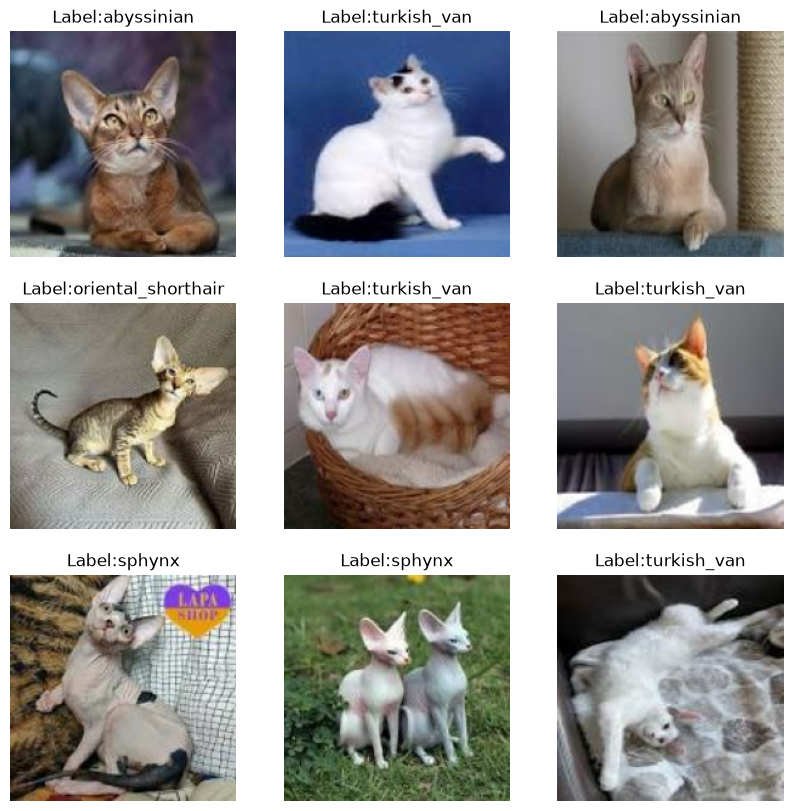

In [23]:
import matplotlib.pyplot as plt
import numpy as np

#display the first 9 images
plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(
            f"Label:{train_ds.class_names[labels[i]]}"
        )
        plt.axis('off')
plt.show()


Step 2: Data Reprocessing

In [26]:
#function to rescale images
def rescale(images, labels):
    return tf.cast(images, tf.float32) / 255.0 , labels

train_ds  = train_ds.map(rescale)
validation_ds = validation_ds.map(rescale)

print(f"train_ds after scaling: {train_ds}")
print(f"validation_ds after scaling: {validation_ds}")


train_ds after scaling: <_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
validation_ds after scaling: <_MapDataset element_spec=(TensorSpec(shape=(None, 180, 180, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


Model Creation

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Input shape: height, width, color channels
    layers.Input(shape=(180, 180, 3)),
    
    # Feature extraction (Convolutions + Pooling)
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flatten features into a 1D vector
    layers.Flatten(),
    
    # Classification head
    layers.Dense(128, activation='relu'),
    layers.Dense(10)
])

#compiling the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics = ['accuracy'])

model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,648,266 (25.36 MB)

 Trainable params: 6,648,266 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

Training the Model

In [33]:
history = model.fit(train_ds, validation_data= validation_ds, epochs= 10)


/home/laurencejhonadominguez/Documents/IAi/reverse_engineered/.venv/lib64/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/10


W0000 00:00:1788537247.557424   56032 cpu_allocator_impl.cc:82] Allocation of 129777664 exceeds 10% of free system memory.
W0000 00:00:1788537247.826236   56030 cpu_allocator_impl.cc:82] Allocation of 62005248 exceeds 10% of free system memory.
W0000 00:00:1788537248.542992   56030 cpu_allocator_impl.cc:82] Allocation of 62005248 exceeds 10% of free system memory.
W0000 00:00:1788537248.830957   56034 cpu_allocator_impl.cc:82] Allocation of 64888832 exceeds 10% of free system memory.
W0000 00:00:1788537248.831216   56034 cpu_allocator_impl.cc:82] Allocation of 129777664 exceeds 10% of free system memory.


34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 933ms/step - accuracy: 0.1667 - loss: 2.3993 - val_accuracy: 0.2119 - val_loss: 2.2450
Epoch 2/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 930ms/step - accuracy: 0.2565 - loss: 2.0981 - val_accuracy: 0.2268 - val_loss: 2.1195
Epoch 3/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 901ms/step - accuracy: 0.2972 - loss: 1.9667 - val_accuracy: 0.1933 - val_loss: 2.0665
Epoch 4/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 892ms/step - accuracy: 0.3630 - loss: 1.8316 - val_accuracy: 0.2565 - val_loss: 2.0090
Epoch 5/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 894ms/step - accuracy: 0.4972 - loss: 1.5068 - val_accuracy: 0.2900 - val_loss: 2.3864
Epoch 6/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 870ms/step - accuracy: 0.6398 - loss: 1.1165 - val_accuracy: 0.2677 - val_loss: 2.8128
Epoch 7/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 29s 865ms/step - accuracy: 0.7824 - loss: 0.6826 - val_accuracy: 0.2788 - val_loss: 3.6224
Epoch 8/10
34/34 ━━━━━━━━━━━━━━━━━━━━ 30s 873ms/step - accuracy: 0.8963 - loss: 0.3534 - val_accuracy: 0.275

Visualize the Training History

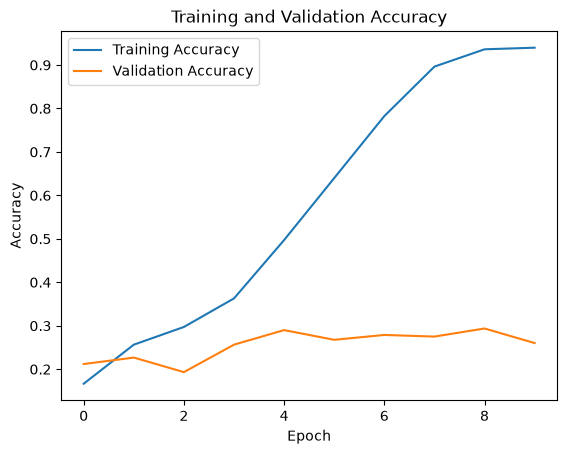

In [ ]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

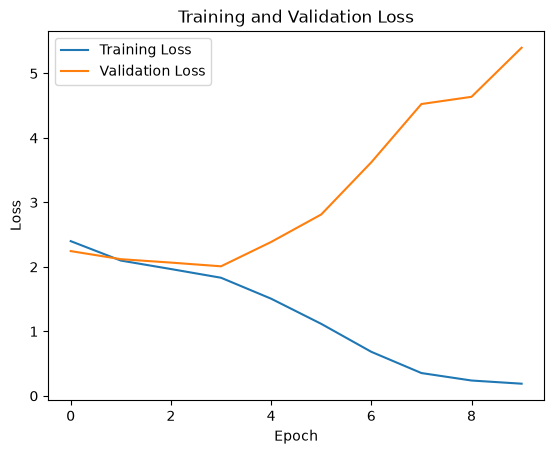

In [35]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Predictions

In [ ]:
# Generate predictions
predictions = model.predict(train_ds)
# Print the shape of the predictions
print("Predictions shape:", predictions.shape)

34/34 ━━━━━━━━━━━━━━━━━━━━ 8s 224ms/step
Predictions shape: (1080, 10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step


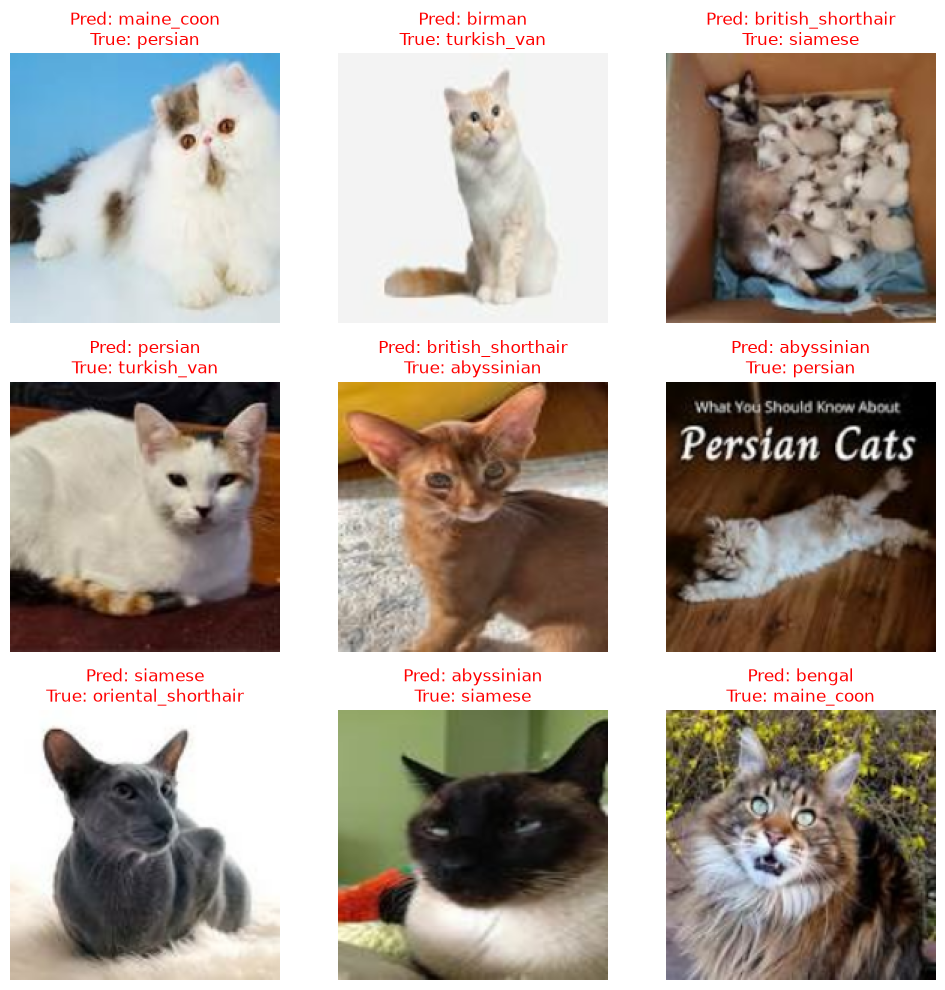

In [45]:
import os
import matplotlib.pyplot as plt
import numpy as np

class_names = sorted(os.listdir("cat_breeds"))
# 1. Grab one batch (32 images and their true labels)
for images, labels in validation_ds.take(1):
    # 2. Predict on this single batch
    batch_predictions = model.predict(images)
    
    # 3. Plot the first 9 images from this batch
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        
        # Display the image
        plt.imshow(images[i].numpy())
        
        # Determine labels
        predicted_label = class_names[np.argmax(batch_predictions[i])]
        actual_label = class_names[labels[i].numpy()]
        
        # Green title if correct, Red if wrong
        color = "green" if predicted_label == actual_label else "red"
        
        plt.title(f"Pred: {predicted_label}\nTrue: {actual_label}", color=color)
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    break

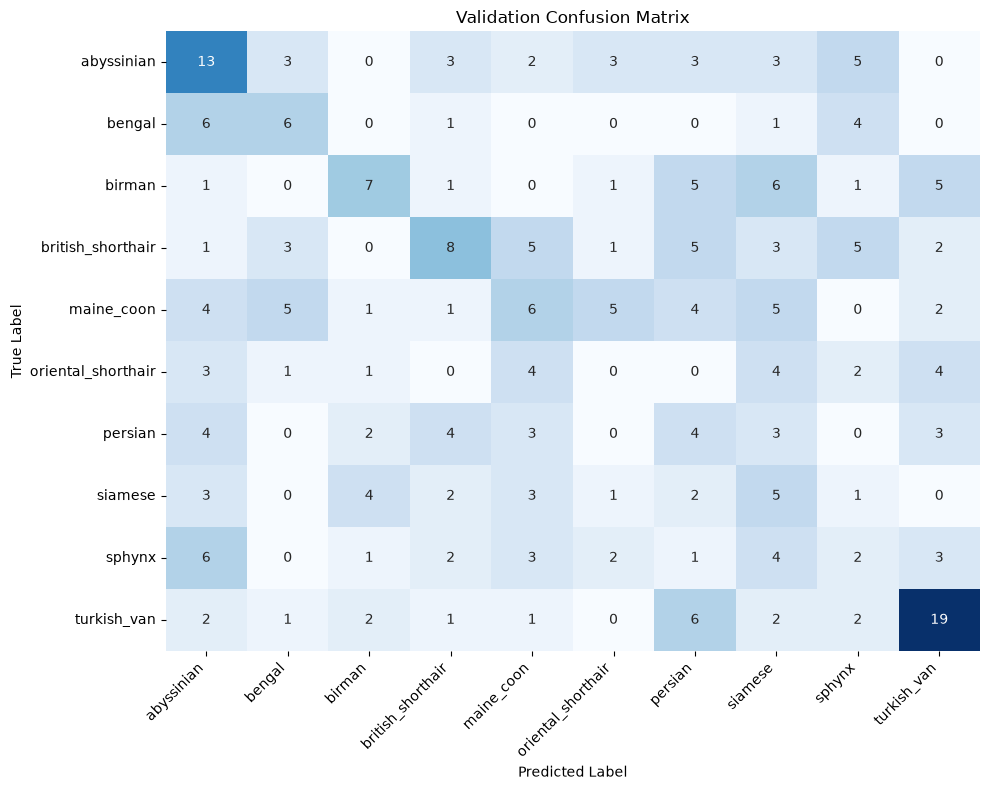

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Extract true labels and predictions from the validation set
true_labels = []
predicted_classes = []

for images, labels in validation_ds:
    preds = model.predict(images, verbose=0)
    predicted_classes.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

# Convert to numpy arrays
true_labels = np.array(true_labels)
predicted_classes = np.array(predicted_classes)

# 2. Compute the confusion matrix
cm = confusion_matrix(true_labels, predicted_classes)

# 3. Plot using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False,
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Validation Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Model evaluation

In [ ]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(train_ds, predicted_classes)

# Print the classification report
print(report)